In [1]:
# =========================================================
# TRIANGULACIÓN: TGEU vs. CARIBE AFIRMATIVO
# ¿Qué tan representativa es la muestra de TGEU frente al mejor
# monitor local disponible en Colombia?
# =========================================================

# --- CELDA 1: Cargar el dataset limpio de TGEU ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

col = pd.read_csv('/content/tgeu_colombia_limpio.csv')
casos_tgeu_por_año = col['Calendar year'].value_counts().sort_index()


In [2]:
# --- CELDA 2: Tabla de referencia — cifras de Caribe Afirmativo ---
# Introducidas manualmente a partir de sus informes anuales públicos
# ('Incontables: Sin registro, no hay memoria', 2023; 'Con permiso
# para despreciar', 2024). Solo se incluyen los años donde el informe
# desagregó específicamente víctimas trans (no el total LGBTIQ+, que
# mezcla poblaciones distintas y no es comparable con TGEU).
CARIBE_AFIRMATIVO_TRANS = {
    2023: 41 + 3 + 2,   # 41 mujeres trans + 3 hombres trans + 2 personas no binarias
    2024: 34 + 8,       # 34 mujeres trans + 8 hombres trans
}
FUENTE = {
    2023: "Informe 'Incontables: Sin registro, no hay memoria' (Caribe Afirmativo, marzo 2024)",
    2024: "Informe 'Con permiso para despreciar' (Caribe Afirmativo, mayo 2025)",
}

comparacion = pd.DataFrame({
    'año': list(CARIBE_AFIRMATIVO_TRANS.keys()),
    'TGEU': [casos_tgeu_por_año.get(a, 0) for a in CARIBE_AFIRMATIVO_TRANS],
    'Caribe_Afirmativo_trans': list(CARIBE_AFIRMATIVO_TRANS.values()),
})
comparacion['cobertura_TGEU_%'] = (comparacion['TGEU'] / comparacion['Caribe_Afirmativo_trans'] * 100).round(1)
print(comparacion)

    año  TGEU  Caribe_Afirmativo_trans  cobertura_TGEU_%
0  2023    26                       46              56.5
1  2024    22                       42              52.4


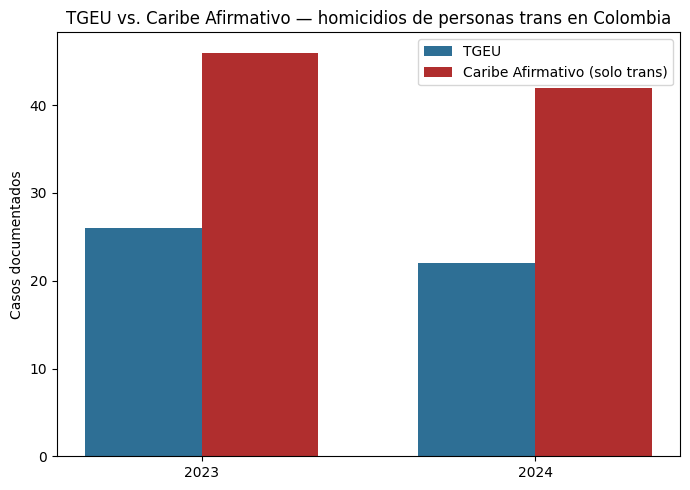

In [3]:
# --- CELDA 3: Gráfico comparativo ---
x = np.arange(len(comparacion))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - ancho/2, comparacion['TGEU'], ancho, label='TGEU', color='#2E6F95')
ax.bar(x + ancho/2, comparacion['Caribe_Afirmativo_trans'], ancho, label='Caribe Afirmativo (solo trans)', color='#B02E2E')
ax.set_xticks(x)
ax.set_xticklabels(comparacion['año'])
ax.set_ylabel('Casos documentados')
ax.set_title('TGEU vs. Caribe Afirmativo — homicidios de personas trans en Colombia')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# --- CELDA 4: Validación del acumulado histórico ---
# TGEU/Statista citan 279 casos acumulados en Colombia entre 2008-2024
# (dato publicado en enero de 2025). Nuestro propio archivo, descargado
# más tarde, recalcula el mismo acumulado para verificar que el filtro
# de país no se equivocó.
total_recalculado = col[col['Calendar year'] <= 2024]['Calendar year'].count()
total_citado_tgeu = 279

print(f"Total TGEU-Colombia 2008-2024 recalculado de nuestro CSV: {total_recalculado}")
print(f"Total citado por TGEU/Statista (enero 2025): {total_citado_tgeu}")
print(f"Diferencia: {total_recalculado - total_citado_tgeu} casos — explicable por la fecha de "
      f"descarga (nuestro archivo es posterior, de agosto 2026). Confirma que el filtro por país "
      f"está bien aplicado, no es un error de extracción.")

Total TGEU-Colombia 2008-2024 recalculado de nuestro CSV: 282
Total citado por TGEU/Statista (enero 2025): 279
Diferencia: 3 casos — explicable por la fecha de descarga (nuestro archivo es posterior, de agosto 2026). Confirma que el filtro por país está bien aplicado, no es un error de extracción.


In [5]:
# --- CELDA 5: Lo que esto significa para el resto del análisis ---
cobertura_promedio = comparacion['cobertura_TGEU_%'].mean()
print(f"\nCobertura promedio de TGEU frente a Caribe Afirmativo (años verificables): "
      f"{cobertura_promedio:.1f}%")
print("\nCONCLUSIÓN PARA EL ARTÍCULO: TGEU no es un caos de subregistro aleatorio —")
print("captura de forma razonablemente estable un poco más de la mitad de los casos")
print("trans documentados en Colombia por el monitor local más completo. Esto no")
print("invalida los hallazgos de los cuadernos anteriores (tendencia, respuesta")
print("institucional, hallazgo de capitales), pero sí implica que las magnitudes")
print("absolutas de TGEU deben leerse como un PISO, no como el total real —y que")
print("aproximadamente la mitad de los casos colombianos documentados por Caribe")
print("Afirmativo simplemente no están en los datos que hemos analizado.")


Cobertura promedio de TGEU frente a Caribe Afirmativo (años verificables): 54.5%

CONCLUSIÓN PARA EL ARTÍCULO: TGEU no es un caos de subregistro aleatorio —
captura de forma razonablemente estable un poco más de la mitad de los casos
trans documentados en Colombia por el monitor local más completo. Esto no
invalida los hallazgos de los cuadernos anteriores (tendencia, respuesta
institucional, hallazgo de capitales), pero sí implica que las magnitudes
absolutas de TGEU deben leerse como un PISO, no como el total real —y que
aproximadamente la mitad de los casos colombianos documentados por Caribe
Afirmativo simplemente no están en los datos que hemos analizado.


In [6]:
# --- CELDA 6: Corroboración cualitativa sobre impunidad ---
# Caribe Afirmativo (2024): 86% de los casos LGBTIQ+ siguen en etapa de
# indagación preliminar, solo 3 casos han llegado a sentencia en todo
# el país. Esto no es la misma métrica exacta que 'hubo_accion' en
# nuestro análisis (que incluye 'investigación en curso' como acción
# identificada), pero apunta en la misma dirección sustantiva:
# impunidad muy alta, de forma independiente en dos fuentes distintas.
print("\nCorroboración cualitativa: Caribe Afirmativo (2024) reporta que 86% de los")
print("casos LGBTIQ+ en Colombia siguen en etapa de indagación preliminar y solo 3")
print("han llegado a sentencia en todo el país — coincide, con metodología propia")
print("e independiente, con el hallazgo de alta impunidad de nuestro propio análisis.")


Corroboración cualitativa: Caribe Afirmativo (2024) reporta que 86% de los
casos LGBTIQ+ en Colombia siguen en etapa de indagación preliminar y solo 3
han llegado a sentencia en todo el país — coincide, con metodología propia
e independiente, con el hallazgo de alta impunidad de nuestro propio análisis.


In [7]:
# --- CELDA 7: Exportar ---
comparacion.to_csv('/content/triangulacion_tgeu_caribe_afirmativo.csv', index=False)
print("\nExportado: triangulacion_tgeu_caribe_afirmativo.csv")


Exportado: triangulacion_tgeu_caribe_afirmativo.csv
